In [6]:
import numpy as np
import os
import glob
import json
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from scipy.stats import levene
from itertools import combinations
import sys
sys.path.append('../../..')
from style_setup import set_thesis_style, WONG_PALETTE
set_thesis_style()

# Helper functions

In [7]:
# ==============================================================================
# HELPER & CORE FUNCTIONS
# ==============================================================================

def _print_header(title):
    """Helper to print a standardized header."""
    print("\n" + "=" * 70)
    print(title.center(70))
    print("=" * 70)

def load_perplexity_data(data_path, datasets_config):
    """Loads perplexity scores from .jsonl files."""
    if not os.path.isdir(data_path):
        print(f"Error: Data directory not found at '{data_path}'")
        return None
        
    perplexities_by_dataset = {}
    filename_to_dataset_name = {filename: name for name, filename in datasets_config}
    
    for file_path in glob.glob(os.path.join(data_path, "ppl*.jsonl")):
        file_name = os.path.basename(file_path)
        if file_name in filename_to_dataset_name:
            dataset_name = filename_to_dataset_name[file_name]
            perplexities = []
            with open(file_path, 'r') as f:
                for line in f:
                    try:
                        data = json.loads(line)
                        perplexity = data.get("token_probabilities", {}).get("perplexity")
                        if perplexity is not None and np.isfinite(perplexity):
                            perplexities.append(perplexity)
                    except json.JSONDecodeError:
                        print(f"Warning: Could not decode JSON from a line in {file_name}")
            perplexities_by_dataset[dataset_name] = perplexities
            
    ordered_perplexities = {
        name: perplexities_by_dataset.get(name, []) 
        for name, _ in datasets_config 
        if name in perplexities_by_dataset
    }
    return ordered_perplexities

def remove_outliers_iqr(perplexities_by_dataset, factor=1.5):
    """Removes outliers using the Interquartile Range (IQR) method."""
    cleaned_data = {}
    _print_header("Outlier Removal using IQR method")
    print(f"Factor: {factor}\n")
    for name, data in perplexities_by_dataset.items():
        if not data:
            cleaned_data[name] = []
            continue
            
        q1 = np.percentile(data, 25)
        q3 = np.percentile(data, 75)
        iqr = q3 - q1
        lower_bound = q1 - (factor * iqr)
        upper_bound = q3 + (factor * iqr)
        
        original_count = len(data)
        filtered_data = [x for x in data if lower_bound <= x <= upper_bound]
        cleaned_data[name] = filtered_data
        
        print(f"Dataset: {name}")
        print(f"  Original Count: {original_count}")
        print(f"  Removed: {original_count - len(filtered_data)}")
        print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  New Count: {len(filtered_data)}\n")
        
    return cleaned_data

def calculate_statistics(perplexities_by_dataset):
    """Calculates descriptive statistics for perplexity scores."""
    stats_data = []
    for name, values in perplexities_by_dataset.items():
        if values:
            stats_data.append({
                "Dataset": name,
                "Count": len(values),
                "Mean": np.mean(values),
                "Median": np.median(values),
                "Variance": np.var(values, ddof=1),
                "Std. Dev.": np.std(values, ddof=1),
            })
    return pd.DataFrame(stats_data).set_index("Dataset")

def plot_perplexity_distributions(perplexities, stats_df, data_size, suffix="", output_path=None):
    fig, ax = plt.subplots(figsize=(3.33, 3.0))

    label_map = {
        "Single-Source": "Single",
        "Multi-Source":  "Multi",
        "Human-Source":  "Human",
        "None (Vanilla)": "Vanilla"
    }

    plot_data = pd.DataFrame([
        {'Dataset': label_map.get(name, name), 'Perplexity': score}
        for name, scores in perplexities.items() for score in scores
    ])
    order = [label_map.get(n, n) for n in perplexities.keys()]

    sns.boxplot(
        data=plot_data, x='Dataset', y='Perplexity', hue='Dataset',
        order=order, palette=WONG_PALETTE, ax=ax, legend=False,
        flierprops={"marker": ".", "markersize": 3,
                    "markerfacecolor": "0.4", "linewidth": 0}
    )

    means = stats_df["Mean"]
    for i, name in enumerate(perplexities.keys()):
        if name in means:
            ax.plot(i, means[name], 'o', color='red', markersize=4,
                    markeredgecolor='black')

    ax.set_xlabel('Finetuning Dataset')
    ax.set_ylabel('Perplexity (log scale)')
    ax.set_yscale('log')
    ax.set_xticklabels(order, rotation=20, ha='center')
    ax.grid(True, alpha=0.3, axis='both')

    fig.tight_layout()
    if output_path:
        os.makedirs(output_path, exist_ok=True)
        filename = f"box_ppl_dist_{data_size}{'_cleaned' if suffix else ''}.png"
        fig.savefig(os.path.join(output_path, filename), dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {os.path.join(output_path, filename)}")
    plt.show()

def plot_perplexity_distributions_no_human(perplexities, stats_df, data_size, suffix="", output_path=None):
    fig, ax = plt.subplots(figsize=(3.33, 3.0))

    label_map = {
        "Single-Source": "Single",
        "Multi-Source":  "Multi",
        "None (Vanilla)": "Vanilla"
    }

    filtered = {k: v for k, v in perplexities.items() if 'human' not in k.lower()}
    plot_data = pd.DataFrame([
        {'Dataset': label_map.get(name, name), 'Perplexity': score}
        for name, scores in filtered.items() for score in scores
    ])
    order = [label_map.get(n, n) for n in filtered.keys()]

    sns.boxplot(
        data=plot_data, x='Dataset', y='Perplexity', hue='Dataset',
        order=order, palette=WONG_PALETTE, ax=ax, legend=False,
        flierprops={"marker": ".", "markersize": 3,
                    "markerfacecolor": "0.4", "linewidth": 0}
    )

    means = stats_df["Mean"]
    for i, name in enumerate(filtered.keys()):
        if name in means:
            ax.plot(i, means[name], 'o', color='red', markersize=4,
                    markeredgecolor='black')

    ax.set_xlabel('Finetuning Dataset')
    ax.set_ylabel('Perplexity (log scale)')
    ax.set_yscale('log')
    ax.set_xticklabels(order, rotation=20, ha='center')
    ax.grid(True, alpha=0.3, axis='both')

    fig.tight_layout()
    if output_path:
        os.makedirs(output_path, exist_ok=True)
        filename = f"box_ppl_dist_{data_size}_no_human{'_cleaned' if suffix else ''}.png"
        fig.savefig(os.path.join(output_path, filename), dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {os.path.join(output_path, filename)}")
    plt.show()

def plot_perplexity_histograms(perplexities, stats_df, data_size, suffix="", output_path=None, xlim=None, ylim=None, bin_width=None):
    """
    Generates and saves separate histogram plots for each dataset, skipping 'Human-Source'.
    Uses a specific color palette for the histogram bars.
    Can specify bin_width to control histogram binning.
    """
    # Colors from style_setup.py
    colors = [
        "#4C72B0",  # blue
        "#55A868",  # green
        "#C44E52",  # red
    ]

    # Filter out 'Human-Source' before plotting
    datasets_to_plot = {name: values for name, values in perplexities.items() if name != 'Human-Source'}

    for i, (name, values) in enumerate(datasets_to_plot.items()):
        # Create individual figure for each dataset
        plt.figure(figsize=(10, 6))
        
        # Assign color from the palette based on the plot index
        bar_color = colors[i % len(colors)]
        
        # Determine the bins for the histogram
        if bin_width:
            # Calculate bin edges based on the specified width
            min_val = np.min(values)
            max_val = np.max(values)
            bins = np.arange(min_val, max_val + bin_width, bin_width)
        else:
            # Default to a fixed number of bins if width is not provided
            bins = 30

        # Create histogram with density=True to show proportions
        plt.hist(values, bins=bins, alpha=0.7, edgecolor='black', linewidth=0.5, density=True, color=bar_color)
        
        # Add mean line
        if name in stats_df.index:
            mean_val = stats_df.loc[name, "Mean"]
            plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                       label=f'Mean: {mean_val:.2f}')
        
        # Add median line
        if name in stats_df.index:
            median_val = stats_df.loc[name, "Median"]
            plt.axvline(median_val, color='green', linestyle='--', linewidth=2, 
                       label=f'Median: {median_val:.2f}')
        
        plt.xlabel('Perplexity', fontsize=14)
        plt.ylabel('Proportion', fontsize=14)
        plt.title(f'Perplexity Distribution: {name}', fontsize=16, fontweight='bold')
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        if xlim:
            plt.xlim(xlim)

        if ylim:
            plt.ylim(ylim)
        
        # Use log scale for x-axis if perplexities are very large
        if max(values) > 1000:
            plt.xscale('log')
        
        plt.tight_layout()
        
        if output_path:
            # Create filename with dataset name
            safe_name = name.replace(' ', '_').replace('/', '_')
            filename = f"hist_ppl_{safe_name}_{data_size}.png"
            plt.savefig(os.path.join(output_path, filename), dpi=300, bbox_inches='tight')
            print(f"Histogram plot for {name} saved to {os.path.join(output_path, filename)}")
        else:
            plt.show()
        
        plt.close()  # Close the figure to free memory


def plot_overlapping_histograms_styled(data_dict, stats_df, data_size, suffix="", output_path=None, xlim=None, ylim=None, bin_width=0.05, log_scale=False):
    """
    Creates and saves an overlapping histogram for two datasets' perplexity distributions,
    styled similarly to the existing plot_perplexity_histograms function.
    """
    if len(data_dict) != 2:
        print("This function is designed to compare exactly two datasets.")
        return

    fig, ax = plt.subplots(figsize=(12, 7))

    # Colors from your existing style
    colors = [
        "#4C72B0",  # blue
        "#55A868",  # green
    ]
    
    dataset_items = list(data_dict.items())

    # Determine shared bins for a fair comparison
    all_data = np.concatenate(list(data_dict.values()))
    if bin_width:
        if xlim:
            min_val, max_val = xlim
        else:
            min_val, max_val = np.min(all_data), np.max(all_data)
        bins = np.arange(min_val, max_val + bin_width, bin_width)
    else:
        bins = 30  # Default number of bins

    # Plot first dataset
    name1, data1 = dataset_items[0]
    ax.hist(data1, bins=bins, color=colors[0], alpha=0.6, density=True, label=name1, edgecolor='black', linewidth=0.5)
    mean_val1 = stats_df.loc[name1, "Mean"]
    median_val1 = stats_df.loc[name1, "Median"]
    ax.axvline(mean_val1, color=colors[0], linestyle='--', linewidth=2, label=f'{name1} Mean: {mean_val1:.2f}')
    ax.axvline(median_val1, color=colors[0], linestyle=':', linewidth=2, label=f'{name1} Median: {median_val1:.2f}')

    # Plot second dataset
    name2, data2 = dataset_items[1]
    ax.hist(data2, bins=bins, color=colors[1], alpha=0.6, density=True, label=name2, edgecolor='black', linewidth=0.5)
    mean_val2 = stats_df.loc[name2, "Mean"]
    median_val2 = stats_df.loc[name2, "Median"]
    ax.axvline(mean_val2, color=colors[1], linestyle='--', linewidth=2, label=f'{name2} Mean: {mean_val2:.2f}')
    ax.axvline(median_val2, color=colors[1], linestyle=':', linewidth=2, label=f'{name2} Median: {median_val2:.2f}')
    
    ax.set_title(f"Perplexity Distributions for {data_size.capitalize()} Models{suffix}", fontsize=18, fontweight='bold')
    ax.set_ylabel("Proportion", fontsize=16)
    ax.set_xlabel("Perplexity", fontsize=16)
    
    # Increase tick label font sizes
    ax.tick_params(axis='both', which='major', labelsize=14)

    if log_scale:
        ax.set_xscale('log')
        ax.set_yscale('log')
        # Remove borders when using log scale
        for patch in ax.patches:
            patch.set_edgecolor('none')

    ax.legend(title="Dataset", fontsize=14, title_fontsize=16, frameon=True, fancybox=True, shadow=False)
    ax.grid(True, alpha=0.3)

    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)

    # Use log scale for x-axis if perplexities are very large
    if np.max(all_data) > 1000:
        ax.set_xscale('log')

    plt.tight_layout()
    
    if output_path:
        filename = f"hist_ppl_overlapping_{data_size}{suffix.replace(' ', '_').lower()}.png"
        filepath = os.path.join(output_path, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {filepath}")
        
    plt.show()
    plt.close(fig) # Close the figure to free memory

def _print_pairwise_results(pairs, results, alpha, test_name):
    """Helper to print pairwise test results in a structured table."""
    bonferroni_alpha = alpha / len(pairs)
    print(f"\nPairwise {test_name} with Bonferroni correction (alpha = {bonferroni_alpha:.2e})")
    results_df = pd.DataFrame(results, columns=['Group 1', 'Group 2', 'Statistic', 'p-value'])
    results_df['Significant'] = results_df['p-value'] < bonferroni_alpha
    results_df['p-value'] = results_df['p-value'].map('{:.2e}'.format)
    results_df['Statistic'] = results_df['Statistic'].map('{:.2f}'.format)
    print(results_df.to_string(index=False))

def run_statistical_test(test_func, perplexities, alpha, title, test_name):
    """A generic runner for overall and pairwise statistical tests."""
    _print_header(title)
    groups = list(perplexities.values())
    group_names = list(perplexities.keys())
    if len(groups) < 2:
        print("Need at least two groups to run tests.")
        return
    stat, p_value = test_func(*groups)
    print(f"Overall Test on groups: {', '.join(group_names)}")
    print(f"Statistic: {stat:.4f}, p-value: {p_value:.3e}")
    is_significant = p_value < alpha
    print(f"Result: The test is {'significant' if is_significant else 'not significant'} at alpha={alpha}.")
    if is_significant:
        pairs = list(combinations(group_names, 2))
        pairwise_results = [
            (g1, g2, *test_func(perplexities[g1], perplexities[g2]))
            for g1, g2 in pairs
        ]
        _print_pairwise_results(pairs, pairwise_results, alpha, test_name)


# Small models

Loading data for 'small' models from: /Users/maxschaffelder/Documents/University/UU/AI Master/Archive/Thesis/data/exp_1/small/perplexity

                  Descriptive Statistics (Raw Data)                   
                Count         Mean    Median      Variance      Std. Dev.
Dataset                                                                  
Single-Source    1502     1.286469  1.254865  3.136981e-02       0.177115
Multi-Source     1502     1.458623  1.353935  1.702328e-01       0.412593
Human-Source     1502  3766.977717  2.500460  1.221978e+10  110543.132722
None (Vanilla)   1502     1.380878  1.284695  1.687208e-01       0.410756

                   Outlier Removal using IQR method                   
Factor: 1.5

Dataset: Single-Source
  Original Count: 1502
  Removed: 61
  Bounds: [0.90, 1.62]
  New Count: 1441

Dataset: Multi-Source
  Original Count: 1502
  Removed: 104
  Bounds: [0.80, 1.98]
  New Count: 1398

Dataset: Human-Source
  Original Count: 1502
  Removed: 14

/var/folders/tb/f4d7bpdj76l65_hkvgy9gjww0000gn/T/ipykernel_16735/1225127877.py:145: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.boxplot(
/var/folders/tb/f4d7bpdj76l65_hkvgy9gjww0000gn/T/ipykernel_16735/1225127877.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=20, ha='center')


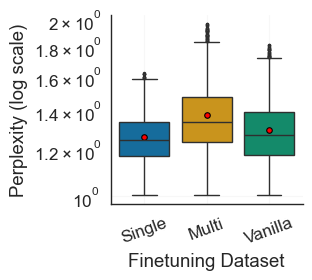

In [8]:
# ==============================================================================
# CONFIGURATION
# ==============================================================================
# Define paths and constants. Change DATA_SIZE to 'medium' to run for other models.

BASE_PATH = "/Users/maxschaffelder/Documents/University/UU/AI Master/Archive/Thesis"
EXPERIMENT = "exp_1" 
DATA_SIZE = "small"
PPL_DATA_PATH = os.path.join(BASE_PATH, "data", EXPERIMENT, DATA_SIZE, "perplexity")
PLOTS_PATH = os.path.join(BASE_PATH, "plots", EXPERIMENT, "ppl")
SIGNIFICANCE_LEVEL = 0.05

# Analysis options
REMOVE_OUTLIERS = True
OUTLIER_REMOVAL_FACTOR = 1.5 # For IQR method: 1.5 is standard, 3 is more conservative

# Define datasets in the desired order for plotting and analysis
DATASETS_CONFIG = [
    ("Single-Source", "ppl_lora_llama_8b_single.jsonl"),
    ("Multi-Source", "ppl_lora_llama_8b_multi.jsonl"),
    ("Human-Source", "ppl_lora_llama_8b_human.jsonl"),
    ("None (Vanilla)", "ppl_vanilla_llama_8b.jsonl")
]

os.makedirs(PLOTS_PATH, exist_ok=True)

# ==============================================================================
# EXECUTION
# ==============================================================================
print(f"Loading data for '{DATA_SIZE}' models from: {PPL_DATA_PATH}")
raw_perplexities = load_perplexity_data(PPL_DATA_PATH, DATASETS_CONFIG)

if raw_perplexities:
    _print_header("Descriptive Statistics (Raw Data)")
    print(calculate_statistics(raw_perplexities))

    final_perplexities = raw_perplexities
    plot_suffix = ""

    if REMOVE_OUTLIERS:
        final_perplexities = remove_outliers_iqr(raw_perplexities, factor=OUTLIER_REMOVAL_FACTOR)
        _print_header("Descriptive Statistics (Cleaned Data)")
        print(calculate_statistics(final_perplexities))
        plot_suffix = " (Outliers Removed)"
    
    # --- Generate Plot ---
    stats_df = calculate_statistics(final_perplexities)
    #plot_perplexity_distributions(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path="/Users/maxschaffelder/Desktop")
    plot_perplexity_distributions_no_human(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path="/Users/maxschaffelder/Desktop")
    #plot_perplexity_histograms(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=None, xlim=(0.8, 2.2), bin_width=0.02)
    
    # --- Perform Statistical Tests on Final Data ---
    #levene_test_func = lambda *args: stats.levene(*args, center='median')
    #run_statistical_test(levene_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Homogeneity of Variance (Levene's Test)", "Levene's")
    
    #kruskal_test_func = lambda *args: stats.kruskal(*args)
    #run_statistical_test(kruskal_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Difference in Distributions (Kruskal-Wallis)", "Mann-Whitney U")
else:
    print("Could not load perplexity data. Please check configuration.")

In [40]:
import json
import os
import random
from pathlib import Path

# Path to outputs directory
outputs_path = Path("/Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/outputs")

# Function to extract and display example responses
def show_example_responses():
    print("=" * 80)
    print("EXAMPLE RESPONSES FROM OUTPUT FILES")
    print("=" * 80)
    
    # Get all JSONL files in outputs directory
    jsonl_files = list(outputs_path.glob("*.jsonl"))
    
    if not jsonl_files:
        print("No JSONL files found in outputs directory")
        return
    
    for file_path in jsonl_files:
        print(f"\n📁 File: {file_path.name}")
        print("-" * 60)
        
        try:
            # Read JSONL file line by line
            with open(file_path, 'r', encoding='utf-8') as f:
                lines = f.readlines()
            
            if not lines:
                print("❌ Empty file")
                continue
            
            # Parse all lines and extract responses and instructions
            all_responses = []
            all_instructions = []
            for line in lines:
                line = line.strip()
                if not line:
                    continue
                    
                try:
                    data = json.loads(line)
                    if "response_model" in data:
                        all_responses.append(data["response_model"])
                    if "instruction" in data:
                        all_instructions.append(data["instruction"])
                except json.JSONDecodeError:
                    continue
            
            if not all_responses:
                print("❌ No valid responses found in this file")
                continue
            
            # Sample 30 responses randomly (or all if less than 30)
            sample_size = min(30, len(all_responses))
            sampled_indices = random.sample(range(len(all_responses)), sample_size)
            sampled_responses = [all_responses[i] for i in sampled_indices]
            sampled_instructions = [all_instructions[i] if i < len(all_instructions) else "No instruction found" for i in sampled_indices]
            
            print(f"Showing {sample_size} randomly sampled responses (out of {len(all_responses)} total):")
            print()
            
            for i, (response, instruction) in enumerate(zip(sampled_responses, sampled_instructions), 1):
                print(f"Response {i}:")
                print(f"Type: {type(response)}")
                print(f"Instruction: {instruction}")
                
                # Handle different response formats
                if isinstance(response, str):
                    # Truncate long responses for display
                    display_text = response[:500] + "..." if len(response) > 500 else response
                    print(f"Content: {display_text}")
                elif isinstance(response, dict):
                    print(f"Content: {json.dumps(response, indent=2, ensure_ascii=False)[:500]}...")
                elif isinstance(response, list):
                    print(f"Content: {str(response)[:500]}...")
                else:
                    print(f"Content: {str(response)[:500]}...")
                print("-" * 40)
                
        except Exception as e:
            print(f"❌ Error reading file: {e}")
        
        print()

# Execute the function
show_example_responses()


EXAMPLE RESPONSES FROM OUTPUT FILES

📁 File: output_lora_llama_8b_human.jsonl
------------------------------------------------------------
Showing 30 randomly sampled responses (out of 1502 total):

Response 1:
Type: <class 'str'>
Instruction: What are some weight loss tips?
Content: - Eat more plant-based foods, such as fruits, vegetables, whole grains, and legumes. These foods are generally low in calories and high in fiber, which can help you feel full and satisfied.
- Incorporate healthy fats into your diet, such as nuts, seeds, avocados, and olive oil. These fats can help you feel full and satisfied, and can also provide essential nutrients.
- Drink plenty of water. Aim to drink at least eight glasses of water per day.
- Exercise regularly. Aim for at least 30 minutes o...
----------------------------------------
Response 2:
Type: <class 'str'>
Instruction: Tell me whether these are movies or books: Jurassic, Harry Potter and the Philosopher's Stone, Angels and Demons
Content: Jur

# Medium models

## Same size finetuning datasets

Loading data for 'medium' models from: /Users/maxschaffelder/Documents/University/UU/AI Master/Archive/Thesis/data/exp_1/medium/perplexity

                  Descriptive Statistics (Raw Data)                   
                Count         Mean    Median      Variance     Std. Dev.
Dataset                                                                 
Single-Source    1502     1.227656  1.145345  6.139376e-01      0.783542
Multi-Source     1502     2.480096  1.247780  1.802197e+03     42.452293
Human-Source     1502  1799.977346  2.243555  2.634596e+09  51328.319499
None (Vanilla)   1502     1.227870  1.201350  2.116982e-02      0.145499

                   Outlier Removal using IQR method                   
Factor: 1.5

Dataset: Single-Source
  Original Count: 1502
  Removed: 90
  Bounds: [0.94, 1.36]
  New Count: 1412

Dataset: Multi-Source
  Original Count: 1502
  Removed: 88
  Bounds: [0.84, 1.69]
  New Count: 1414

Dataset: Human-Source
  Original Count: 1502
  Removed: 137
  B

/var/folders/tb/f4d7bpdj76l65_hkvgy9gjww0000gn/T/ipykernel_16735/1225127877.py:145: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.boxplot(
/var/folders/tb/f4d7bpdj76l65_hkvgy9gjww0000gn/T/ipykernel_16735/1225127877.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=20, ha='center')


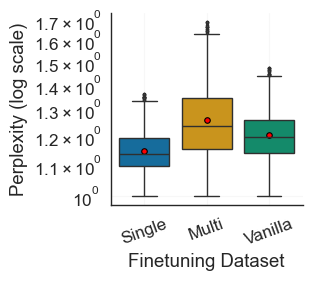

In [9]:
# ==============================================================================
# CONFIGURATION
# ==============================================================================
# Define paths and constants. Change DATA_SIZE to 'medium' to run for other models.

BASE_PATH = "/Users/maxschaffelder/Documents/University/UU/AI Master/Archive/Thesis"
EXPERIMENT = "exp_1" 
MODEL_SIZE = "medium"
DATA_SIZE = "medium"
PPL_DATA_PATH = os.path.join(BASE_PATH, "data", EXPERIMENT, MODEL_SIZE, "perplexity")
PLOTS_PATH = os.path.join(BASE_PATH, "plots", EXPERIMENT, "ppl", "llama_70b")
SIGNIFICANCE_LEVEL = 0.05

# Analysis options
REMOVE_OUTLIERS = True
OUTLIER_REMOVAL_FACTOR = 1.5 # For IQR method: 1.5 is standard, 3 is more conservative

# Define datasets in the desired order for plotting and analysis
DATASETS_CONFIG = [
    ("Single-Source", f"ppl_lora_llama_70b_single_{DATA_SIZE}.jsonl"),
    ("Multi-Source", f"ppl_lora_llama_70b_multi_{DATA_SIZE}.jsonl"),
    ("Human-Source", "ppl_lora_llama_70b_human.jsonl"),
    ("None (Vanilla)", "ppl_vanilla_llama_70b.jsonl")
]

os.makedirs(PLOTS_PATH, exist_ok=True)

# ==============================================================================
# EXECUTION
# ==============================================================================
print(f"Loading data for '{MODEL_SIZE}' models from: {PPL_DATA_PATH}")
raw_perplexities = load_perplexity_data(PPL_DATA_PATH, DATASETS_CONFIG)

if raw_perplexities:
    _print_header("Descriptive Statistics (Raw Data)")
    print(calculate_statistics(raw_perplexities))

    final_perplexities = raw_perplexities
    plot_suffix = ""

    if REMOVE_OUTLIERS:
        final_perplexities = remove_outliers_iqr(raw_perplexities, factor=OUTLIER_REMOVAL_FACTOR)
        _print_header("Descriptive Statistics (Cleaned Data)")
        print(calculate_statistics(final_perplexities))
        plot_suffix = " (Outliers Removed)"
    
    # --- Generate Plot ---
    stats_df = calculate_statistics(final_perplexities)
    #plot_perplexity_distributions(final_perplexities, stats_df, MODEL_SIZE, suffix=plot_suffix, output_path="/Users/maxschaffelder/Desktop")
    plot_perplexity_distributions_no_human(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path="/Users/maxschaffelder/Desktop")
    #plot_perplexity_histograms(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=PLOTS_PATH, xlim=(0.8, 1.8), ylim=(0, 6.5), bin_width=0.02)
    
    # --- Perform Statistical Tests on Final Data ---
    #levene_test_func = lambda *args: stats.levene(*args, center='median')
    #run_statistical_test(levene_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Homogeneity of Variance (Levene's Test)", "Levene's")
    
    #kruskal_test_func = lambda *args: stats.kruskal(*args)
    #run_statistical_test(kruskal_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Difference in Distributions (Kruskal-Wallis)", "Mann-Whitney U")
else:
    print("Could not load perplexity data. Please check configuration.")

## Different size finetuning datasets

### Single-source

In [15]:
# ==============================================================================
# CONFIGURATION
# ==============================================================================
# Define paths and constants. Change DATA_SIZE to 'medium' to run for other models.

BASE_PATH = "/Users/maxschaffelder/Desktop/Thesis"
EXPERIMENT = "exp_1" 
DATA_SIZE = "medium"
PPL_DATA_PATH = os.path.join(BASE_PATH, "data", EXPERIMENT, DATA_SIZE, "perplexity")
PLOTS_PATH = os.path.join(BASE_PATH, "plots", EXPERIMENT, "ppl")
SIGNIFICANCE_LEVEL = 0.05

# Analysis options
REMOVE_OUTLIERS = False
OUTLIER_REMOVAL_FACTOR = 1.5 # For IQR method: 1.5 is standard, 3 is more conservative

# Define datasets in the desired order for plotting and analysis
DATASETS_CONFIG = [
    ("Single-Source Small", "ppl_lora_llama_70b_single_small.jsonl"),
    ("Single-Source Medium", "ppl_lora_llama_70b_single_medium.jsonl"),
    ("Single-Source Large", "ppl_lora_llama_70b_single_large.jsonl")
]

os.makedirs(PLOTS_PATH, exist_ok=True)

# ==============================================================================
# EXECUTION
# ==============================================================================
print(f"Loading data for '{DATA_SIZE}' models from: {PPL_DATA_PATH}")
raw_perplexities = load_perplexity_data(PPL_DATA_PATH, DATASETS_CONFIG)

if raw_perplexities:
    _print_header("Descriptive Statistics (Raw Data)")
    print(calculate_statistics(raw_perplexities))

    final_perplexities = raw_perplexities
    plot_suffix = ""

    if REMOVE_OUTLIERS:
        final_perplexities = remove_outliers_iqr(raw_perplexities, factor=OUTLIER_REMOVAL_FACTOR)
        _print_header("Descriptive Statistics (Cleaned Data)")
        print(calculate_statistics(final_perplexities))
        plot_suffix = " (Outliers Removed)"
    
    # --- Generate Plot ---
    stats_df = calculate_statistics(final_perplexities)
    #plot_perplexity_distributions(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=PLOTS_PATH)
    #plot_perplexity_distributions_no_human(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=PLOTS_PATH)
    #plot_perplexity_histograms(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=PLOTS_PATH, xlim=(0.8, 1.8), ylim=(0, 6.5), bin_width=0.02)
    
    # --- Perform Statistical Tests on Final Data ---
    #levene_test_func = lambda *args: stats.levene(*args, center='median')
    #run_statistical_test(levene_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Homogeneity of Variance (Levene's Test)", "Levene's")
    
    kruskal_test_func = lambda *args: stats.kruskal(*args)
    run_statistical_test(kruskal_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Difference in Distributions (Kruskal-Wallis)", "Mann-Whitney U")
else:
    print("Could not load perplexity data. Please check configuration.")

Loading data for 'medium' models from: /Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/perplexity

                  Descriptive Statistics (Raw Data)                   
                      Count      Mean    Median  Variance  Std. Dev.
Dataset                                                             
Single-Source Small    1502  1.353900  1.264475  0.618788   0.786630
Single-Source Medium   1502  1.227656  1.145345  0.613938   0.783542
Single-Source Large    1502  1.251893  1.170225  0.611069   0.781709

             Difference in Distributions (Kruskal-Wallis)             
Overall Test on groups: Single-Source Small, Single-Source Medium, Single-Source Large
Statistic: 609.4642, p-value: 4.534e-133
Result: The test is significant at alpha=0.05.

Pairwise Mann-Whitney U with Bonferroni correction (alpha = 1.67e-02)
             Group 1              Group 2 Statistic   p-value  Significant
 Single-Source Small Single-Source Medium    540.84 1.24e-119         True
 Single-So

### Multi-source

In [16]:
# ==============================================================================
# CONFIGURATION
# ==============================================================================
# Define paths and constants. Change DATA_SIZE to 'medium' to run for other models.

BASE_PATH = "/Users/maxschaffelder/Desktop/Thesis"
EXPERIMENT = "exp_1" 
DATA_SIZE = "medium"
PPL_DATA_PATH = os.path.join(BASE_PATH, "data", EXPERIMENT, DATA_SIZE, "perplexity")
PLOTS_PATH = os.path.join(BASE_PATH, "plots", EXPERIMENT, "ppl")
SIGNIFICANCE_LEVEL = 0.05

# Analysis options
REMOVE_OUTLIERS = False
OUTLIER_REMOVAL_FACTOR = 1.5 # For IQR method: 1.5 is standard, 3 is more conservative

# Define datasets in the desired order for plotting and analysis
DATASETS_CONFIG = [
    ("Multi-Source Small", "ppl_lora_llama_70b_multi_small.jsonl"),
    ("Multi-Source Medium", "ppl_lora_llama_70b_multi_medium.jsonl"),
    ("Multi-Source Large", "ppl_lora_llama_70b_multi_large.jsonl")
]

os.makedirs(PLOTS_PATH, exist_ok=True)

# ==============================================================================
# EXECUTION
# ==============================================================================
print(f"Loading data for '{DATA_SIZE}' models from: {PPL_DATA_PATH}")
raw_perplexities = load_perplexity_data(PPL_DATA_PATH, DATASETS_CONFIG)

if raw_perplexities:
    _print_header("Descriptive Statistics (Raw Data)")
    print(calculate_statistics(raw_perplexities))

    final_perplexities = raw_perplexities
    plot_suffix = ""

    if REMOVE_OUTLIERS:
        final_perplexities = remove_outliers_iqr(raw_perplexities, factor=OUTLIER_REMOVAL_FACTOR)
        _print_header("Descriptive Statistics (Cleaned Data)")
        print(calculate_statistics(final_perplexities))
        plot_suffix = " (Outliers Removed)"
    
    # --- Generate Plot ---
    stats_df = calculate_statistics(final_perplexities)
    #plot_perplexity_distributions(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=None)
    #plot_perplexity_distributions_no_human(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=PLOTS_PATH)
    #plot_perplexity_histograms(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=PLOTS_PATH, xlim=(0.8, 2.2), ylim=(0, 3.5), bin_width=0.02)
    
    # --- Perform Statistical Tests on Final Data ---
    #levene_test_func = lambda *args: stats.levene(*args, center='median')
    #run_statistical_test(levene_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Homogeneity of Variance (Levene's Test)", "Levene's")
    
    kruskal_test_func = lambda *args: stats.kruskal(*args)
    run_statistical_test(kruskal_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Difference in Distributions (Kruskal-Wallis)", "Mann-Whitney U")
else:
    print("Could not load perplexity data. Please check configuration.")

Loading data for 'medium' models from: /Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/perplexity

                  Descriptive Statistics (Raw Data)                   
                     Count      Mean    Median     Variance  Std. Dev.
Dataset                                                               
Multi-Source Small    1502  1.539557  1.358615     0.859703   0.927202
Multi-Source Medium   1502  2.480096  1.247780  1802.197152  42.452293
Multi-Source Large    1502  1.541715  1.422140     0.721399   0.849352

             Difference in Distributions (Kruskal-Wallis)             
Overall Test on groups: Multi-Source Small, Multi-Source Medium, Multi-Source Large
Statistic: 385.8335, p-value: 1.649e-84
Result: The test is significant at alpha=0.05.

Pairwise Mann-Whitney U with Bonferroni correction (alpha = 1.67e-02)
            Group 1             Group 2 Statistic  p-value  Significant
 Multi-Source Small Multi-Source Medium    218.83 1.63e-49         True
 Multi-Sou

# Combined dataframe

In [20]:
import pandas as pd
import json
import os
import numpy as np
from glob import glob

# Define the paths to the directories
path_medium = '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/perplexity/'
path_small = '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/perplexity'

# Get all jsonl files from both directories
files_medium = glob(os.path.join(path_medium, '*.jsonl'))
files_small = glob(os.path.join(path_small, '*.jsonl'))
all_files = files_medium + files_small

# List to store the statistics
results = []

def parse_filename(filename):
    """Parses the filename to extract model and data characteristics."""
    info = {}
    filename_base = os.path.basename(filename)

    # Model Size
    if '70b' in filename_base:
        info['Model Size'] = '70B'
    elif '8b' in filename_base:
        info['Model Size'] = '8B'
    else:
        info['Model Size'] = 'N/A'

    # Finetuning Data
    if 'vanilla' in filename_base:
        info['Finetuning Data'] = 'Vanilla (None)'
        info['Finetuning Data Size'] = 'N/A'
        return info  # Early exit for vanilla models
    
    # Finetuning Data
    if 'human' in filename_base:
        info['Finetuning Data'] = 'Human'
    elif 'multi' in filename_base:
        info['Finetuning Data'] = 'Multi-Source'
    elif 'single' in filename_base:
        info['Finetuning Data'] = 'Single-Source'
    else:
        info['Finetuning Data'] = 'N/A'

    # Finetuning Data Size
    if 'large' in filename_base:
        info['Finetuning Data Size'] = 'Large'
    elif 'medium' in filename_base:
        info['Finetuning Data Size'] = 'Medium'
    elif 'small' in filename_base:
        info['Finetuning Data Size'] = 'Small'
    else:
        # Infer size if not present in filename
        if info['Model Size'] == '8B' and info['Finetuning Data'] != 'Human':
            info['Finetuning Data Size'] = 'Small'
        elif info['Model Size'] == '70B' and info['Finetuning Data'] != 'Human':
            info['Finetuning Data Size'] = 'Medium'
        else:
            info['Finetuning Data Size'] = 'N/A'
            
    return info

# Process each file
for file_path in all_files:
    perplexities = []
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    data = json.loads(line)
                    if 'token_probabilities' in data and data["token_probabilities"]["perplexity"] is not None:
                        perplexities.append(data["token_probabilities"]["perplexity"])
                except json.JSONDecodeError:
                    print(f"Warning: Could not decode JSON from a line in {file_path}")
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")
        continue

    if perplexities:
        mean_ppl = np.mean(perplexities)
        median_ppl = np.median(perplexities)
        variance_ppl = np.var(perplexities)
        std_ppl = np.std(perplexities)
        
        file_info = parse_filename(file_path)
        
        results.append({
            'Filename': os.path.basename(file_path),
            'Model Size': file_info.get('Model Size', 'N/A'),
            'Finetuning Data': file_info.get('Finetuning Data', 'N/A'),
            'Finetuning Data Size': file_info.get('Finetuning Data Size', 'N/A'),
            'Mean': mean_ppl,
            'Median': median_ppl,
            'Variance': variance_ppl,
            'Std': std_ppl
        })

# Create DataFrame
df = pd.DataFrame(results)

# For better display in notebooks
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    print(df)

df.to_csv('perplexity_stats.csv', index=False)


                                  Filename Model Size Finetuning Data Finetuning Data Size         Mean    Median      Variance            Std
0    ppl_lora_llama_70b_multi_medium.jsonl        70B    Multi-Source               Medium     2.480096  1.247780  1.800997e+03      42.438158
1     ppl_lora_llama_70b_multi_large.jsonl        70B    Multi-Source                Large     1.541715  1.422140  7.209185e-01       0.849069
2    ppl_lora_llama_70b_single_large.jsonl        70B   Single-Source                Large     1.251893  1.170225  6.106621e-01       0.781449
3              ppl_vanilla_llama_70b.jsonl        70B  Vanilla (None)                  N/A     1.227870  1.201350  2.115573e-02       0.145450
4   ppl_lora_llama_70b_single_medium.jsonl        70B   Single-Source               Medium     1.227656  1.145345  6.135288e-01       0.783281
5           ppl_lora_llama_70b_human.jsonl        70B           Human                  N/A  1799.977346  2.243555  2.632842e+09   51311.229996

## Outliers removed using IQR method

In [19]:
import pandas as pd
import json
import os
import numpy as np
from glob import glob

# Define the paths to the directories
path_medium = '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/perplexity/'
path_small = '/Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/perplexity'

# Get all jsonl files from both directories
files_medium = glob(os.path.join(path_medium, '*.jsonl'))
files_small = glob(os.path.join(path_small, '*.jsonl'))
all_files = files_medium + files_small

# List to store the statistics
results = []

def parse_filename(filename):
    """Parses the filename to extract model and data characteristics."""
    info = {}
    filename_base = os.path.basename(filename)

    # Model Size
    if '70b' in filename_base:
        info['Model Size'] = '70B'
    elif '8b' in filename_base:
        info['Model Size'] = '8B'
    else:
        info['Model Size'] = 'N/A'

    # Finetuning Data
    if 'vanilla' in filename_base:
        info['Finetuning Data'] = 'Vanilla (None)'
        info['Finetuning Data Size'] = 'N/A'
        return info  # Early exit for vanilla models
    
    # Finetuning Data
    if 'human' in filename_base:
        info['Finetuning Data'] = 'Human'
    elif 'multi' in filename_base:
        info['Finetuning Data'] = 'Multi-Source'
    elif 'single' in filename_base:
        info['Finetuning Data'] = 'Single-Source'
    else:
        info['Finetuning Data'] = 'N/A'

    # Finetuning Data Size
    if 'large' in filename_base:
        info['Finetuning Data Size'] = 'Large'
    elif 'medium' in filename_base:
        info['Finetuning Data Size'] = 'Medium'
    elif 'small' in filename_base:
        info['Finetuning Data Size'] = 'Small'
    else:
        # Infer size if not present in filename
        if info['Model Size'] == '8B' and info['Finetuning Data'] != 'Human':
            info['Finetuning Data Size'] = 'Small'
        elif info['Model Size'] == '70B' and info['Finetuning Data'] != 'Human':
            info['Finetuning Data Size'] = 'Medium'
        else:
            info['Finetuning Data Size'] = 'N/A'
            
    return info

# Process each file
for file_path in all_files:
    perplexities = []
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    data = json.loads(line)
                    if 'token_probabilities' in data and data["token_probabilities"]["perplexity"] is not None:
                        perplexities.append(data["token_probabilities"]["perplexity"])
                except json.JSONDecodeError:
                    print(f"Warning: Could not decode JSON from a line in {file_path}")
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")
        continue

    if perplexities:
        # --- IQR outlier removal ---
        initial_count = len(perplexities)
        perplexities_np = np.array(perplexities)
        
        Q1 = np.percentile(perplexities_np, 25)
        Q3 = np.percentile(perplexities_np, 75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        perplexities_filtered = [p for p in perplexities if p >= lower_bound and p <= upper_bound]
        removed_count = initial_count - len(perplexities_filtered)
        
        print(f"File: {os.path.basename(file_path):<45} | Outliers removed: {removed_count:>4} / {initial_count}")

        # Calculate stats on the filtered list
        if perplexities_filtered:
             mean_ppl = np.mean(perplexities_filtered)
             median_ppl = np.median(perplexities_filtered)
             variance_ppl = np.var(perplexities_filtered)
             std_ppl = np.std(perplexities_filtered)
        else: # Handle case where all data is considered outliers
             mean_ppl = np.nan
             median_ppl = np.nan
             variance_ppl = np.nan
             print(f"  - Warning: All data points were considered outliers in {os.path.basename(file_path)}")
        
        file_info = parse_filename(file_path)
        
        results.append({
            'Filename': os.path.basename(file_path),
            'Model Size': file_info.get('Model Size', 'N/A'),
            'Finetuning Data': file_info.get('Finetuning Data', 'N/A'),
            'Finetuning Data Size': file_info.get('Finetuning Data Size', 'N/A'),
            'Mean': mean_ppl,
            'Median': median_ppl,
            'Variance': variance_ppl,
            'Std': std_ppl
        })

# Create DataFrame
df = pd.DataFrame(results)

# For better display in notebooks
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    print("\nPerplexity Statistics (Outliers Removed):")
    print(df)

df.to_csv('perplexity_stats_no_outliers.csv', index=False)

File: ppl_lora_llama_70b_multi_medium.jsonl         | Outliers removed:   88 / 1502
File: ppl_lora_llama_70b_multi_large.jsonl          | Outliers removed:   74 / 1502
File: ppl_lora_llama_70b_single_large.jsonl         | Outliers removed:   77 / 1502
File: ppl_vanilla_llama_70b.jsonl                   | Outliers removed:   79 / 1502
File: ppl_lora_llama_70b_single_medium.jsonl        | Outliers removed:   90 / 1502
File: ppl_lora_llama_70b_human.jsonl                | Outliers removed:  137 / 1502
File: ppl_lora_llama_70b_single_small.jsonl         | Outliers removed:   80 / 1502
File: ppl_lora_llama_70b_multi_small.jsonl          | Outliers removed:  104 / 1502
File: ppl_lora_llama_8b_multi.jsonl                 | Outliers removed:  104 / 1502
File: ppl_lora_llama_8b_human.jsonl                 | Outliers removed:  148 / 1502
File: ppl_vanilla_llama_8b.jsonl                    | Outliers removed:  110 / 1502
File: ppl_lora_llama_8b_single.jsonl                | Outliers removed:   61

# Looking into perplexities in llama-medium multi-source medium (high mean/variance)

In [6]:
import json
import numpy as np

# Load the perplexity data
file_path = "/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/perplexity/ppl_lora_llama_70b_multi_medium.jsonl"

# Read the JSONL file and extract perplexity values with their corresponding data
entries = []
with open(file_path, 'r') as f:
    for line in f:
        data = json.loads(line.strip())
        perplexity = data["token_probabilities"]["perplexity"]
        instruction = data.get('instruction', '')
        response_model = data.get('response_model', '')
        entries.append({
            'perplexity': perplexity,
            'instruction': instruction,
            'response_model': response_model
        })

# Extract all perplexity values for statistical analysis
all_perplexities = [entry['perplexity'] for entry in entries]

# Calculate statistics with all data
mean_all = np.mean(all_perplexities)
median_all = np.median(all_perplexities)
variance_all = np.var(all_perplexities)
std_all = np.std(all_perplexities)

# Calculate statistics without the highest perplexity value
perplexities_without_max = all_perplexities.copy()
perplexities_without_max.remove(max(perplexities_without_max))
mean_without_max = np.mean(perplexities_without_max)
median_without_max = np.median(perplexities_without_max)
variance_without_max = np.var(perplexities_without_max)
std_without_max = np.std(perplexities_without_max)

print(f"Statistical Analysis for {file_path}:")
print("=" * 80)
print(f"Total number of entries: {len(all_perplexities)}")
print(f"Highest perplexity value: {max(all_perplexities)}")
print(f"\nWith all data:")
print(f"  Mean: {mean_all}")
print(f"  Median: {median_all}")
print(f"  Variance: {variance_all}")
print(f"  Standard Deviation: {std_all}")
print(f"\nWithout highest perplexity value:")
print(f"  Mean: {mean_without_max}")
print(f"  Median: {median_without_max}")
print(f"  Variance: {variance_without_max}")
print(f"  Standard Deviation: {std_without_max}")
print(f"  Difference in mean: {mean_all - mean_without_max}")
print(f"  Difference in median: {median_all - median_without_max}")
print(f"  Difference in variance: {variance_all - variance_without_max}")
print(f"  Difference in std: {std_all - std_without_max}")

# Sort by perplexity in descending order and get top 10
entries.sort(key=lambda x: x['perplexity'], reverse=True)
top_10_entries = entries[:3]

print(f"\nTop 3 highest perplexity values from {file_path}:")
print("=" * 80)

for i, entry in enumerate(top_10_entries, 1):
    print(f"\n{i}. Perplexity: {entry['perplexity']}")
    print(f"Instruction: {entry['instruction']}")
    print(f"Response: {entry['response_model']}")
    print("-" * 80)


Statistical Analysis for /Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/perplexity/ppl_lora_llama_70b_multi_medium.jsonl:
Total number of entries: 1502
Highest perplexity value: 1646.24133

With all data:
  Mean: 2.480096018641811
  Median: 1.2477800000000001
  Variance: 1800.9972873455515
  Standard Deviation: 42.43815838777116

Without highest perplexity value:
  Mean: 1.38498526982012
  Median: 1.2472
  Variance: 0.8972889122394508
  Standard Deviation: 0.947253351664406
  Difference in mean: 1.095110748821691
  Difference in median: 0.0005800000000000249
  Difference in variance: 1800.099998433312
  Difference in std: 41.49090503610675

Top 3 highest perplexity values from /Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/perplexity/ppl_lora_llama_70b_multi_medium.jsonl:

1. Perplexity: 1646.24133
Instruction: Choose the word which is different from the rest: Barley, Rice, Wheat, Mustard, Bajra.
Response: Mustard
--------------------------------------------------------

In [4]:
import json
import numpy as np
import os
import glob

# Define the directory paths
perplexity_dir = "/Users/maxschaffelder/Desktop/Thesis/data/exp_1/medium/perplexity"

# Get all JSONL files in the perplexity directory
jsonl_files = glob.glob(os.path.join(perplexity_dir, "*.jsonl"))

# Process each file
for file_path in jsonl_files:
    # Read the JSONL file and extract perplexity values
    perplexities = []
    with open(file_path, 'r') as f:
        for line in f:
            data = json.loads(line.strip())
            perplexity = data["token_probabilities"]["perplexity"]
            perplexities.append(perplexity)
    
    # Sort perplexities in descending order and get top 10
    perplexities.sort(reverse=True)
    top_10_perplexities = perplexities[:10]
    
    # Get just the filename without path
    filename = os.path.basename(file_path)
    
    print(f"{filename}: {top_10_perplexities}")


ppl_lora_llama_70b_multi_medium.jsonl: [1646.24133, 16.24459, 12.42751, 12.04978, 11.88544, 11.8412, 11.82702, 11.53332, 11.49382, 11.05447]
ppl_lora_llama_70b_multi_large.jsonl: [12.42751, 12.04978, 11.88544, 11.8412, 11.82702, 11.53332, 11.49382, 11.05447, 5.2943, 4.7952]
ppl_lora_llama_70b_single_large.jsonl: [12.42751, 12.04978, 11.88544, 11.8412, 11.82702, 11.53332, 11.49382, 11.05447, 2.1843, 2.10258]
ppl_vanilla_llama_70b.jsonl: [2.42971, 2.31982, 2.1985, 2.04913, 2.03071, 2.0289, 2.02314, 1.96605, 1.95559, 1.93163]
ppl_lora_llama_70b_single_medium.jsonl: [12.42751, 12.04978, 11.88544, 11.8412, 11.82702, 11.53332, 11.49382, 11.05447, 3.07479, 2.81734]
ppl_lora_llama_70b_human.jsonl: [1862630.0, 696013.9375, 53392.04297, 49589.05078, 12550.30176, 6511.01074, 6181.97461, 3325.49902, 2001.3158, 1973.328]
ppl_lora_llama_70b_single_small.jsonl: [12.42751, 12.04978, 11.88544, 11.8412, 11.82702, 11.53332, 11.49382, 11.05447, 2.49122, 2.48901]
ppl_lora_llama_70b_multi_small.jsonl: [12.4

# Compare distributions of Llama-70-single-medium and Llama-70b-vanilla

Loading data for 'small' models from: /Users/maxschaffelder/Desktop/Thesis/data/exp_1/small/perplexity

                  Descriptive Statistics (Raw Data)                   
                Count      Mean    Median  Variance  Std. Dev.
Dataset                                                       
Single-Source    1502  1.286469  1.254865  0.031370   0.177115
None (Vanilla)   1502  1.380878  1.284695  0.168721   0.410756


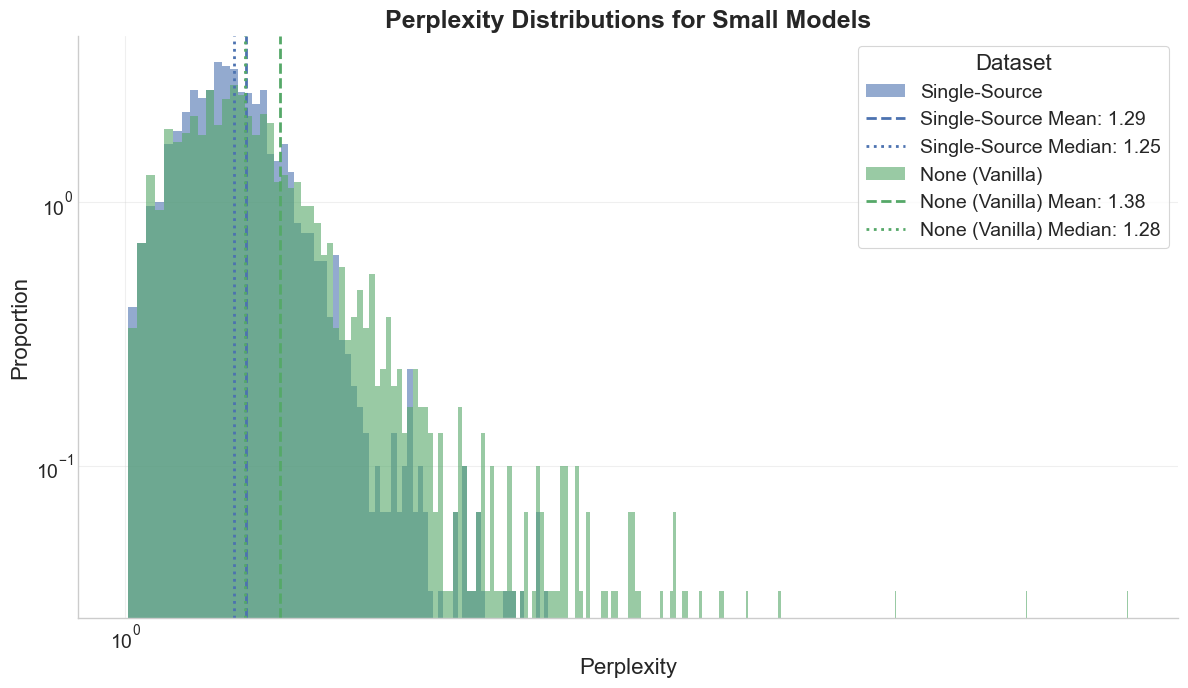


             Difference in Distributions (Kruskal-Wallis)             
Overall Test on groups: Single-Source, None (Vanilla)
Statistic: 32.0243, p-value: 1.523e-08
Result: The test is significant at alpha=0.05.

Pairwise Mann-Whitney U with Bonferroni correction (alpha = 5.00e-02)
      Group 1        Group 2 Statistic  p-value  Significant
Single-Source None (Vanilla)     32.02 1.52e-08         True


In [54]:
# ==============================================================================
# CONFIGURATION
# ==============================================================================
# Define paths and constants. Change DATA_SIZE to 'medium' to run for other models.

BASE_PATH = "/Users/maxschaffelder/Desktop/Thesis"
EXPERIMENT = "exp_1" 
DATA_SIZE = "small"
PPL_DATA_PATH = os.path.join(BASE_PATH, "data", EXPERIMENT, DATA_SIZE, "perplexity")
PLOTS_PATH = os.path.join(BASE_PATH, "plots", EXPERIMENT, "ppl")
SIGNIFICANCE_LEVEL = 0.05

# Analysis options
REMOVE_OUTLIERS = False
OUTLIER_REMOVAL_FACTOR = 1.5 # For IQR method: 1.5 is standard, 3 is more conservative

# Define datasets in the desired order for plotting and analysis
DATASETS_CONFIG = [
    ("Single-Source", "ppl_lora_llama_8b_single.jsonl"),
    ("None (Vanilla)", "ppl_vanilla_llama_8b.jsonl")
]

os.makedirs(PLOTS_PATH, exist_ok=True)

# ==============================================================================
# EXECUTION
# ==============================================================================
print(f"Loading data for '{DATA_SIZE}' models from: {PPL_DATA_PATH}")
raw_perplexities = load_perplexity_data(PPL_DATA_PATH, DATASETS_CONFIG)

if raw_perplexities:
    _print_header("Descriptive Statistics (Raw Data)")
    print(calculate_statistics(raw_perplexities))

    final_perplexities = raw_perplexities
    plot_suffix = ""

    if REMOVE_OUTLIERS:
        final_perplexities = remove_outliers_iqr(raw_perplexities, factor=OUTLIER_REMOVAL_FACTOR)
        _print_header("Descriptive Statistics (Cleaned Data)")
        print(calculate_statistics(final_perplexities))
        plot_suffix = " (Outliers Removed)"
    
    # --- Generate Plot ---
    stats_df = calculate_statistics(final_perplexities)
    #plot_perplexity_distributions(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=PLOTS_PATH)
    #plot_perplexity_distributions_no_human(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=None)
    #plot_perplexity_histograms(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=None, xlim=(0.8, 2.5), ylim=(0, 6.5), bin_width=0.02)
    plot_overlapping_histograms_styled(final_perplexities, stats_df, DATA_SIZE, suffix=plot_suffix, output_path=None, bin_width=0.02, log_scale=True)
    
    # --- Perform Statistical Tests on Final Data ---
    #levene_test_func = lambda *args: stats.levene(*args, center='median')
    #run_statistical_test(levene_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Homogeneity of Variance (Levene's Test)", "Levene's")
    
    kruskal_test_func = lambda *args: stats.kruskal(*args)
    run_statistical_test(kruskal_test_func, final_perplexities, SIGNIFICANCE_LEVEL, "Difference in Distributions (Kruskal-Wallis)", "Mann-Whitney U")
else:
    print("Could not load perplexity data. Please check configuration.")